In [2]:
#import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1. Creation rasterio variables

b2B = rasterio.open('B2.tif')
b3G = rasterio.open('B3.tif')
b4R = rasterio.open('B4.tif')
b8N = rasterio.open('B8.tif')
b11S = rasterio.open('B11.tif')

In [9]:
# 1. Checking parameters of the imagery Shape, Resolution, Crs

print('Details of band b2 (Blue band) - shape', b2B.shape,'Resolution ', b2B.res, 'CRS ', b2B.crs, 'No Data ', b2B.nodata)
print('Details of band b3 (Green band) - shape', b3G.shape,'Resolution ', b3G.res, 'CRS ', b3G.crs, 'No Data ', b3G.nodata)
print('Details of band b4 (Red band) - shape', b4R.shape,'Resolution ', b4R.res, 'CRS ', b4R.crs, 'No Data ', b4R.nodata)
print('Details of band b8 (NIR band) - shape', b8N.shape,'Resolution ', b8N.res, 'CRS ', b8N.crs, 'No Data ', b8N.nodata)
print('Details of band b11 (SWIR band) - shape', b11S.shape,'Resolution ', b11S.res, 'CRS ', b11S.crs, 'No Data ', b11S.nodata)


Details of band b2 (Blue band) - shape (2019, 1426) Resolution  (10.0, 10.0) CRS  EPSG:32644 No Data  65535.0
Details of band b3 (Green band) - shape (2019, 1426) Resolution  (10.0, 10.0) CRS  EPSG:32644 No Data  65535.0
Details of band b4 (Red band) - shape (2019, 1426) Resolution  (10.0, 10.0) CRS  EPSG:32644 No Data  65535.0
Details of band b8 (NIR band) - shape (2019, 1426) Resolution  (10.0, 10.0) CRS  EPSG:32644 No Data  65535.0
Details of band b11 (SWIR band) - shape (1010, 714) Resolution  (20.0, 20.0) CRS  EPSG:32644 No Data  65535.0


In [11]:
# Rasterio reads the pixel values from Band 4 (Red) and Band 8 (Near-Infrared). The (1) specifies that it is reading the first layer/channel of each TIFF image.
#.astype("float32"): Satellite imagery is naturally stored as integers (like 16-bit integers ranging from 0 to 65535). 
#.astype This converts those integer values into decimal numbers (floating-point). 
#Actions (), Connections ., and Text ''

red = b4R.read(1).astype('float32')
nir = b8N.read(1).astype('float32')

In [19]:
#• np.ma.masked_equal(..., -99999): This tells NumPy to find every pixel that has a value of exactly -99999 and mask it out (hide it from calculations).
#• Why do this? In satellite data, empty spaces, borders, or cloud gaps where sensors failed to collect information are filled with a specific fallback number (often -99999 or 65535.0 as seen in your cell 4 output). 
# If you don't mask these out, the massive negative numbers will ruin your NDVI math in line 7 and skew your entire analysis.

red = np.ma.masked_equal(red,-99999)
nir = np.ma.masked_equal(nir, -99999)

In [20]:
# Calculation Indices Healthy plants with abundant chlorophyll absorb most of the red light , Healthy plants reflect a massive amount of NIR light.
ndvi = (nir-red) / (red + nir) 

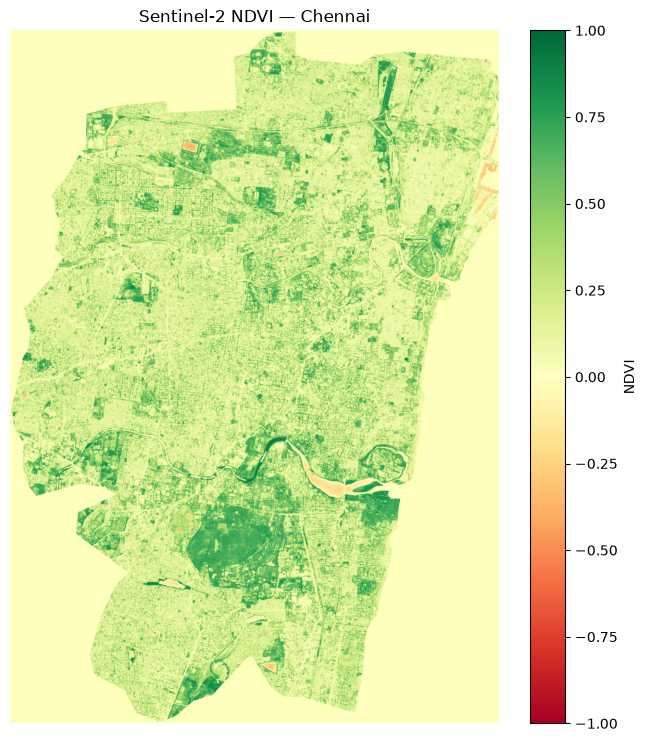

<function matplotlib.pyplot.show(close=None, block=None)>

In [27]:
plt.figure(figsize=(8,9))
plt.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(label = 'NDVI')
plt.title ("Sentinel-2 NDVI — Chennai")
plt.axis('off')

# Save the output directly to specific location
plt.savefig(
    r"C:\Users\HP\Desktop\Day_16\chennai_ndvi_map.jpeg", 
    dpi=300, 
    bbox_inches="tight", 
    facecolor="white"
)

plt.show()


In [37]:
#NDWI ndwi = (green - nir) / (green + nir)
#NIR is already declaired in NDVI as nir


green = b3G.read(1).astype('float32')
#nir = b8N.read(1).astype('float32')
green = np.ma.masked_equal(green,-99999)
#nir = np.ma.masked_equal(nir, -99999)

#Calculation of NDWI 

ndwi = (green - nir) / (green + nir)

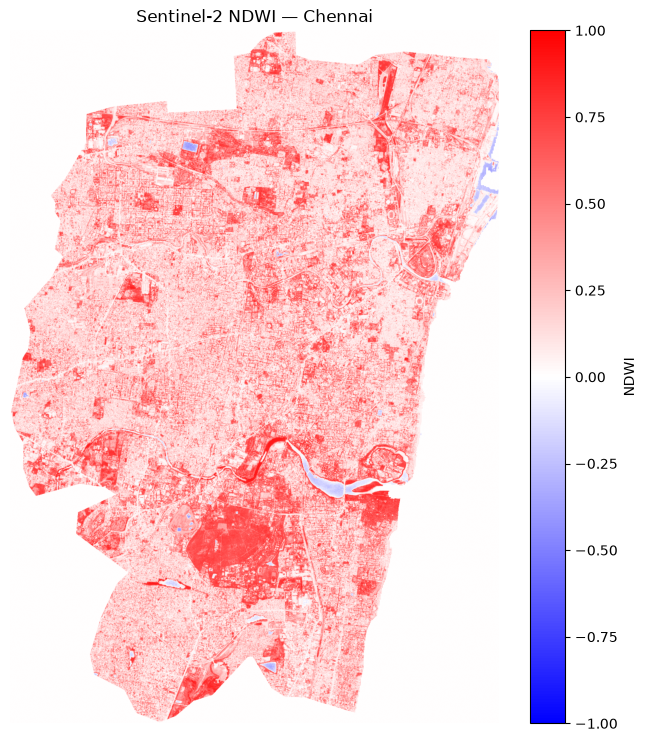

In [38]:
# plot the map and save it as  C:\Users\HP\Desktop\Day_16\chennai_ndwi_map.jpeg

plt.figure(figsize= (8 , 9 ))
plt.imshow(

    ndvi,
    cmap= "bwr",
    vmin=-1,
    vmax=1
)
plt.colorbar(label = 'NDWI')
plt.title ("Sentinel-2 NDWI — Chennai")
plt.axis('off')


plt.savefig(

    r'C:\Users\HP\Desktop\Day_16\chennai_ndwi_map.jpeg',
    dpi=300, 
    bbox_inches="tight", 
    facecolor="white"
)

plt.show()



In [42]:
from rasterio.warp import reproject
from rasterio.enums import Resampling

In [45]:
# Resampling and Transform 

# In Sentinel-2 imagery, different spectral bands have different spatial resolutions. For example, the Near-Infrared band (Band 8) has a sharp 10-meter resolution, 
# - while the Short-Wave Infrared band (Band 11) has a coarser 20-meter resolution. To perform math across these bands, they must have the exact same grid dimensions.

# read the swir band and convert to float

swir = b11S.read(1).astype("float32")

# Creates an empty NumPy array (a blank grid matrix).
# (b8.height, b8.width): Forces this new array to have the exact height and width dimensions of Band 8 (the high-resolution target grid).

swir_resampled = np.empty(
    (b8N.height, b8N.width),
    dtype="float32"
)


# Reproject function to warp and stretch the coarse Band 11 data onto the finer Band 8 grid:
# src_transform & src_crs: Defines the original geographic coordinate location and system of Band 11.
# dst_transform & dst_crs: Defines the target location and coordinate reference system of Band 8.
# src_nodata & dst_nodata: Identifies -99999 as a placeholder value for missing data or borders so the code doesn't confuse it with real imagery measurements.
# resampling=Resampling.bilinear: Uses bilinear interpolation to smoothly calculate the missing values when upscaling the pixels from 20m to 10m resolution.

reproject(
    source=swir,
    destination=swir_resampled,
    src_transform=b11S.transform,
    src_crs=b11S.crs,
    dst_transform=b8N.transform,
    dst_crs=b8N.crs,
    src_nodata=-99999,
    dst_nodata=-99999,
    resampling=Resampling.bilinear
)


# Prints the layout dimensions (rows and columns) of both grids to the console. This lets the user verify that both bands now share the exact same grid dimensions.

print("B8N shape:", b8N.read(1).shape)
print("Resampled B11 shape:", swir_resampled.shape)

swir_resampled = np.ma.masked_equal(
    swir_resampled,
    -99999
)

B8N shape: (2019, 1426)
Resampled B11 shape: (2019, 1426)


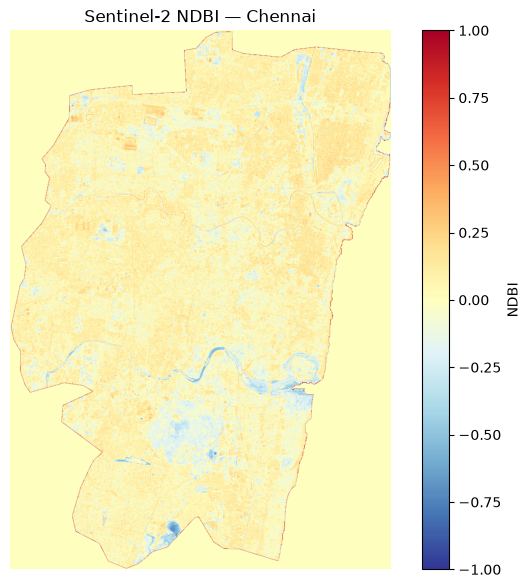

In [47]:
#NDBI
ndbi = (
    swir_resampled - nir
) / (
    swir_resampled + nir
)


plt.figure(figsize=(8, 7))

plt.imshow(
    ndbi,
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDBI")

plt.title("Sentinel-2 NDBI — Chennai")

plt.axis("off")

plt.savefig(

    r'C:\Users\HP\Desktop\Day_16\chennai_NDBI_map.jpeg',
    dpi=300, 
    bbox_inches="tight", 
    facecolor="white"
)

plt.show()
